In [1]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from ncmcm.data_loaders.matlab_dataset import Database
from ncmcm.bundlenet.bundlenet import BunDLeNet, train_model
from ncmcm.bundlenet.utils import prep_data, timeseries_train_test_split


/home/akshey/Desktop/PhD/Code_repositories/comparison-algorithms/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-18 10:44:47,188	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
os.getcwd()

'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results/c_elegans_results/bundlenet_parameter_experiments'

# C. elegans

   latent_dim  markov_loss  behaviour_loss  total_loss
0           1     0.014592        0.050384    0.064976
1           1     0.012418        0.053704    0.066122
2           1     0.011436        0.047307    0.058743
3           1     0.011478        0.049618    0.061096
4           1     0.010987        0.049410    0.060397


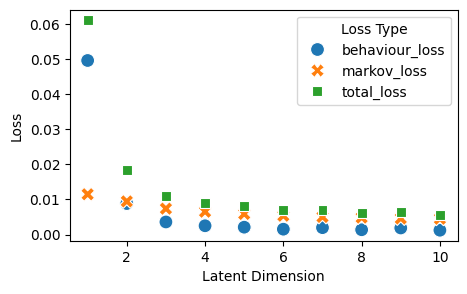

In [12]:
algorithm = 'BunDLeNet'
# Plotting
results = np.load(f'../../data/generated/bunlenet_parameter_experiments/losses_vs_latent_dim_{algorithm}.npy', allow_pickle=True)
df = pd.DataFrame.from_dict(list(results))
print(df.head())

df_melted = df.melt(id_vars='latent_dim', value_vars=['markov_loss', 'behaviour_loss', 'total_loss'],
                    var_name='Loss Type', value_name='Loss')
df_melted = df_melted.groupby(['latent_dim', 'Loss Type'], as_index=False).median()

plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_melted, x='latent_dim', y='Loss', hue='Loss Type', style='Loss Type', s=100)
plt.xlabel('Latent Dimension')
plt.ylabel('Loss')
plt.show()

   win  markov_loss  behaviour_loss  total_loss
0    0     0.002271        0.170655    0.172926
1    0     0.002284        0.170588    0.172872
2    0     0.002268        0.170304    0.172572
3    0     0.002223        0.170750    0.172973
4    0     0.002270        0.170612    0.172882


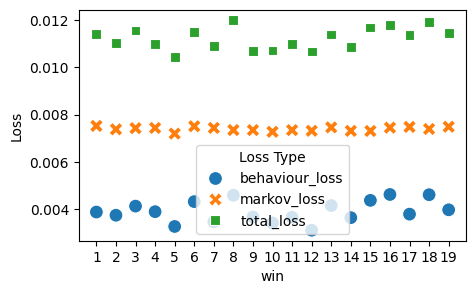

In [21]:
algorithm = 'BunDLeNet'
# Plotting
results = np.load(f'../../data/generated/bunlenet_parameter_experiments/losses_vs_win_{algorithm}.npy', allow_pickle=True)
df = pd.DataFrame.from_dict(list(results))
print(df.head())

df_melted = df.melt(id_vars='win', value_vars=['markov_loss', 'behaviour_loss', 'total_loss'],
                    var_name='Loss Type', value_name='Loss')
df_melted = df_melted.groupby(['win', 'Loss Type'], as_index=False).median()
df_melted = df_melted[df_melted['win'] != 0]

plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_melted, x='win', y='Loss', hue='Loss Type', style='Loss Type', s=100)
plt.xticks(np.arange(1,20))
plt.xlabel('win')
plt.ylabel('Loss')
#plt.yscale('log')
plt.show()

# Rat

   latent_dim  markov_loss  behaviour_loss  total_loss
0           1     0.004758        0.008875    0.013632
1           1     0.004854        0.008942    0.013796
2           1     0.004855        0.008880    0.013735
3           1     0.004829        0.008907    0.013735
4           1     0.004862        0.008876    0.013738


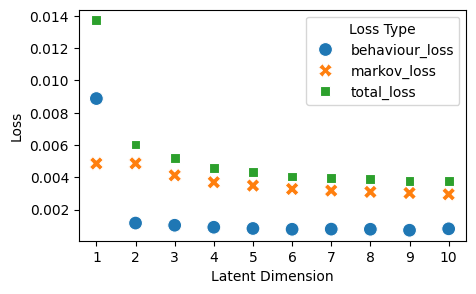

In [10]:
algorithm = 'BunDLeNet'
rat_name = 'achilles'
# Plotting
results = np.load(f'../../data/generated/bunlenet_parameter_experiments/losses_vs_latent_dim_{algorithm}_rat_{rat_name}.npy', allow_pickle=True)
df = pd.DataFrame.from_dict(list(results))
print(df.head())

df_melted = df.melt(id_vars='latent_dim', value_vars=['markov_loss', 'behaviour_loss', 'total_loss'],
                    var_name='Loss Type', value_name='Loss')
df_melted = df_melted.groupby(['latent_dim', 'Loss Type'], as_index=False).median()

plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_melted, x='latent_dim', y='Loss', hue='Loss Type', style='Loss Type', s=100)
plt.xticks(np.arange(1,11))
plt.xlabel('Latent Dimension')
plt.ylabel('Loss')
plt.show()

   win  markov_loss  behaviour_loss  total_loss
0    1     0.005457        0.006344    0.011801
1    1     0.005338        0.006279    0.011617
2    1     0.005325        0.006536    0.011861
3    1     0.005389        0.006442    0.011831
4    1     0.005332        0.006014    0.011346


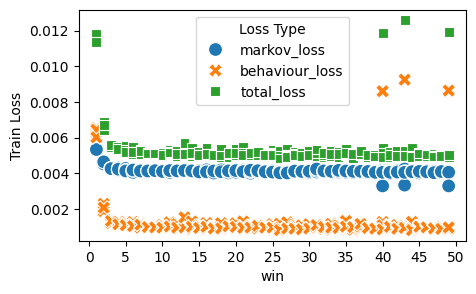

In [22]:
algorithm = 'BunDLeNet'
rat_name = 'achilles'
# Plotting
results = np.load(f'../../data/generated/bunlenet_parameter_experiments/losses_vs_win_{algorithm}_rat_{rat_name}.npy', allow_pickle=True)
df = pd.DataFrame.from_dict(list(results))
print(df.head())

df_melted = df.melt(id_vars='win', value_vars=['markov_loss', 'behaviour_loss', 'total_loss'],
                    var_name='Loss Type', value_name='Loss')

plt.figure(figsize=(5, 3))
#sns.boxenplot(data=df_melted, x='win', y='Loss', hue='Loss Type')
sns.scatterplot(data=df_melted, x='win', y='Loss', hue='Loss Type', style='Loss Type', s=100)
plt.xticks(np.arange(0,51,5))
plt.xlabel('win')
plt.ylabel('Loss')
plt.show()